# 18 · Markov chain Monte Carlo

When we cannot sample a distribution π directly - a Bayesian posterior, a spin system, a configuration of
interacting particles - we can often build a Markov chain whose stationary law is π and run it. Detailed
balance (notebook 06) tells us how: the Metropolis-Hastings acceptance rule. This notebook tunes random-walk
Metropolis, meets the Gibbs sampler and its weakness, uses gradients in Hamiltonian Monte Carlo, simulates the
Ising model across its phase transition, and diagnoses chains with autocorrelation times and R-hat.

**What you will learn**
- construct Metropolis-Hastings samplers and tune their proposals
- use Gibbs sampling and recognise when it mixes slowly
- apply Hamiltonian Monte Carlo with the leapfrog integrator
- diagnose convergence with R-hat, autocorrelation and effective sample size

**Before you start:** notebooks 06 and 14  ·  **Time:** about 90 min

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from engstoch import mcmc, output as oa
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## Random-walk Metropolis and its tuning

In [2]:
logp = lambda x: -0.5 * np.sum(x**2)
rows = []
for d in (1, 10, 50):
    for s in (0.1, 2.38, 10.0):
        r = mcmc.metropolis(logp, np.zeros(d), 20_000, s / np.sqrt(d), R(d))
        rows.append((d, f"{s}/sqrt(d)", r["acceptance"], oa.iat(r["chain"][2000:, 0])["tau"] if r["acceptance"] > 0 else np.inf))
print(pd.DataFrame(rows, columns=["dimension", "proposal sd", "acceptance", "IAT of x_1"]).to_string(index=False, float_format="%.3f"))
ad = mcmc.metropolis(logp, np.zeros(50), 40_000, 1.0, R(5), adapt_until=10_000)
print(f"\nadaptive scaling in d = 50: acceptance {ad['acceptance']:.3f}, final scale {ad['final_scale'][0]:.3f} (2.38/sqrt(50) = {2.38 / np.sqrt(50):.3f})")

 dimension  proposal sd  acceptance  IAT of x_1
         1  0.1/sqrt(d)       0.966     346.785
         1 2.38/sqrt(d)       0.445       4.266
         1 10.0/sqrt(d)       0.122      14.104
        10  0.1/sqrt(d)       0.963    1258.043
        10 2.38/sqrt(d)       0.266      38.493
        10 10.0/sqrt(d)       0.000         inf
        50  0.1/sqrt(d)       0.966    1995.668
        50 2.38/sqrt(d)       0.241      75.153
        50 10.0/sqrt(d)       0.000         inf



adaptive scaling in d = 50: acceptance 0.236, final scale 0.338 (2.38/sqrt(50) = 0.337)


Propose x′ = x + sZ and accept with probability min(1, π(x′)/π(x)): detailed balance holds for any s, but the
efficiency does not. Tiny steps are always accepted and go nowhere; huge steps are always rejected. For
Gaussian-like targets the optimal scale is 2.38/√d with acceptance 0.234 (Roberts, Gelman and Gilks), and the
integrated autocorrelation time still grows linearly with the dimension. Adapting the scale during burn-in
finds it automatically.

## A Bayesian posterior

posterior means [-3.091  0.837]  sds [1.111 0.256]  correlation -0.909
intercept: R-hat 1.0017, ESS 935 of 60000 draws, 95 % credible interval [-5.558 -1.156]
slope: R-hat 1.0020, ESS 907 of 60000 draws, 95 % credible interval [0.408 1.42 ]


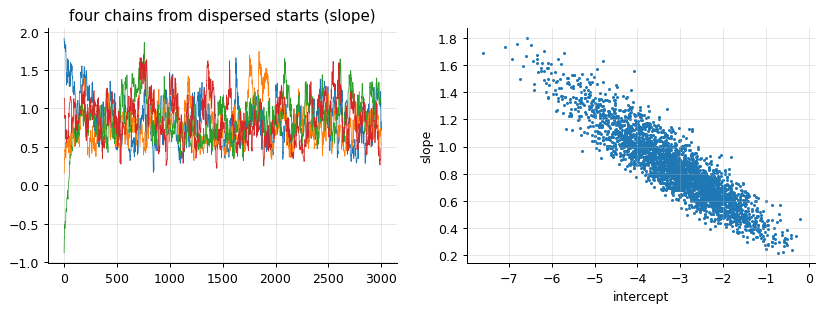

In [3]:
rng = R(6)
x = rng.random(40) * 10
y = (rng.random(40) < 1 / (1 + np.exp(-(-3.0 + 0.8 * x)))).astype(float)
def log_post(b):
    eta = b[0] + b[1] * x
    return float(np.sum(y * eta - np.logaddexp(0, eta)) - 0.5 * np.sum(b**2) / 100)
chains = [mcmc.metropolis(log_post, start, 20_000, [0.6, 0.12], R(10 + k))["chain"] for k, start in enumerate([[-5, 2], [0, 0], [3, -1], [-1, 1.5]])]
post = np.vstack([c[5000:] for c in chains])
print("posterior means", post.mean(axis=0).round(3), " sds", post.std(axis=0).round(3), " correlation", np.corrcoef(post.T)[0, 1].round(3))
for j, name in enumerate(["intercept", "slope"]):
    rh = oa.gelman_rubin([c[10_000:, j] for c in chains])["R_hat"]
    print(f"{name}: R-hat {rh:.4f}, ESS {sum(oa.ess(c[5000:, j]) for c in chains):.0f} of {len(post)} draws, 95 % credible interval {np.quantile(post[:, j], [0.025, 0.975]).round(3)}")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for c in chains: ax[0].plot(c[:3000, 1], lw=0.6)
ax[0].set_title("four chains from dispersed starts (slope)"); ax[1].scatter(post[::20, 0], post[::20, 1], s=2); ax[1].set_xlabel("intercept"); ax[1].set_ylabel("slope"); plt.show()

For a logistic regression the posterior is known only up to its normalising constant - which is all Metropolis
needs. Several chains from dispersed starting points let R-hat compare between- and within-chain variance;
values near 1 and an adequate effective sample size are the minimum evidence of convergence. The strong
posterior correlation between intercept and slope is what slows the chain down.

## Gibbs sampling and its weakness

  rho  IAT of x (measured)  (1 + rho^2)/(1 - rho^2)  sample corr
0.000                1.044                    1.000        0.002
0.500                1.739                    1.667        0.506
0.900                9.583                    9.526        0.904
0.990               92.950                   99.503        0.991


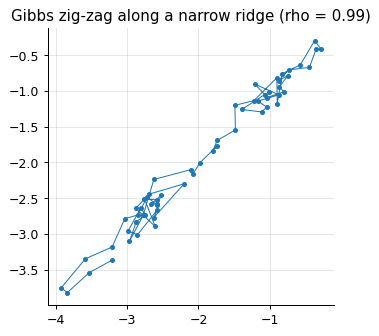

In [4]:
rows = []
for rho in (0.0, 0.5, 0.9, 0.99):
    g = mcmc.gibbs_bivariate_normal(rho, 50_000, R(7))
    rows.append((rho, oa.iat(g[:, 0])["tau"], (1 + rho**2) / (1 - rho**2), np.corrcoef(g.T)[0, 1]))
print(pd.DataFrame(rows, columns=["rho", "IAT of x (measured)", "(1 + rho^2)/(1 - rho^2)", "sample corr"]).to_string(index=False, float_format="%.3f"))
g = mcmc.gibbs_bivariate_normal(0.99, 60, R(8), x0=(-3.0, -3.0))
plt.plot(g[:, 0], g[:, 1], "o-", ms=3, lw=0.8); plt.title("Gibbs zig-zag along a narrow ridge (rho = 0.99)"); plt.gca().set_aspect("equal"); plt.show()

Gibbs sampling updates one coordinate at a time from its full conditional - no tuning, every move accepted.
But it can only move parallel to the axes, so along a narrow diagonal ridge it crawls: the chain of x is an
AR(1) with coefficient ρ², and the autocorrelation time explodes as ρ → 1. Reparametrising (centring, blocking
correlated coordinates) is the cure.

## Hamiltonian Monte Carlo

In [5]:
scales = np.array([1.0, 10.0])
lp = lambda z: -0.5 * np.sum((z / scales) ** 2)
glp = lambda z: -z / scales**2
for step, L in ((0.3, 10), (0.9, 20), (2.1, 20)):
    h = mcmc.hmc(lp, glp, np.zeros(2), 4000, step, L, R(9))
    tau = oa.iat(h["chain"][500:, 1])["tau"] if h["acceptance"] > 0.01 else np.inf
    print(f"HMC step {step}, {L} leapfrog steps: acceptance {h['acceptance']:.3f}, IAT of the wide coordinate {tau:.1f}, sd {h['chain'][500:, 1].std():.2f} (10)")
rw = mcmc.metropolis(lp, np.zeros(2), 40_000, 2.0, R(10))
print(f"random-walk Metropolis, same target: acceptance {rw['acceptance']:.3f}, IAT {oa.iat(rw['chain'][2000:, 1])['tau']:.1f} per (cheaper) step")
errs = [abs(mcmc.leapfrog_energy_error(lambda z: -z, lambda z: -0.5 * float(np.sum(z**2)), [1.0], [0.5], h_, int(round(2 / h_)))) for h_ in (0.2, 0.1, 0.05)]
print("leapfrog energy error for step 0.2, 0.1, 0.05:", np.round(errs, 6), "-> second order")

HMC step 0.3, 10 leapfrog steps: acceptance 0.999, IAT of the wide coordinate 25.5, sd 9.03 (10)


HMC step 0.9, 20 leapfrog steps: acceptance 0.986, IAT of the wide coordinate 0.6, sd 9.91 (10)


HMC step 2.1, 20 leapfrog steps: acceptance 0.000, IAT of the wide coordinate inf, sd 0.00 (10)


random-walk Metropolis, same target: acceptance 0.490, IAT 341.5 per (cheaper) step
leapfrog energy error for step 0.2, 0.1, 0.05: [0.004993 0.001248 0.000312] -> second order


HMC treats −log π as a potential, draws a random momentum, and follows Hamilton's equations with the leapfrog
integrator for many steps before a single accept/reject; the integrator is symplectic and nearly conserves the
energy, so long, distant moves are accepted. An integrated autocorrelation time below 1 means
successive draws are *negatively* correlated - better than independent for estimating the mean. The step size
must suit the *narrowest* direction: above twice the smallest scale (here 2) the leapfrog is unstable, the
energy error explodes and nothing is accepted - the price of not preconditioning.

## The Ising model and a phase transition

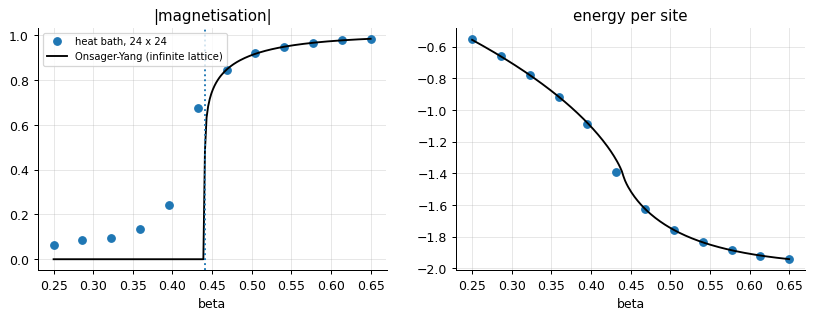

beta = 0.3500: IAT of the magnetisation 7 sweeps


beta = 0.4407: IAT of the magnetisation 50 sweeps


beta = 0.5500: IAT of the magnetisation 5 sweeps


In [6]:
betas = np.linspace(0.25, 0.65, 12)
mags, ens = [], []
for b in betas:
    r = mcmc.ising(24, b, 1200, R(int(1000 * b)), "heatbath")
    mags.append(np.abs(r["magnetisation"][200:]).mean()); ens.append(r["energy"][200:].mean())
bb = np.linspace(0.25, 0.65, 200)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(betas, mags, "o", label="heat bath, 24 x 24"); ax[0].plot(bb, [mcmc.onsager_magnetisation(b) for b in bb], "k", label="Onsager-Yang (infinite lattice)"); ax[0].axvline(mcmc.BETA_C, ls=":"); ax[0].legend(fontsize=8); ax[0].set_xlabel("beta"); ax[0].set_title("|magnetisation|")
ax[1].plot(betas, ens, "o"); ax[1].plot(bb, [mcmc.onsager_energy(b) for b in bb], "k"); ax[1].set_xlabel("beta"); ax[1].set_title("energy per site"); plt.show()
for b in (0.35, mcmc.BETA_C, 0.55):
    r = mcmc.ising(32, b, 2000, R(11), "metropolis", start="hot")
    print(f"beta = {b:.4f}: IAT of the magnetisation {oa.iat(r['magnetisation'][300:])['tau']:.0f} sweeps")

Below the critical inverse temperature β_c = ½ln(1 + √2) spins are disordered; above it they align. Local
Markov chains reproduce Onsager's exact energy and the Onsager-Yang magnetisation away from β_c (the finite
lattice rounds the transition), but near β_c the autocorrelation time explodes - critical slowing down - which
cluster algorithms (Swendsen-Wang, Wolff) were invented to defeat.

## Inside the algorithm: one Metropolis step

In [7]:
g = R(60); x = np.array([0.5]); lp = logp(x)
y = x + 1.0 * g.standard_normal(1); ly = logp(y)
alpha = min(1.0, np.exp(ly - lp)); accept = g.random() < alpha
print(f"proposal {y[0]:.3f}: acceptance probability {alpha:.3f} -> {'accepted' if accept else 'rejected (stay at x)'}")

proposal -0.551: acceptance probability 0.973 -> accepted


## Exercises
1. Sample the posterior of the logistic regression in this notebook with HMC (write the gradient) and compare effective samples per second with random-walk Metropolis.
2. Sample a mixture of two well-separated normals (means -4 and 4) with random-walk Metropolis from several starts. Show that R-hat detects the failure, then fix it with parallel tempering between two temperatures.
3. **Implement it yourself:** write the checkerboard Metropolis sweep for the Ising model from scratch and reproduce the energy per site at beta = 0.3 against `mcmc.onsager_energy`.